<a href="https://colab.research.google.com/github/tomz3302/Egyptian-Currency-Classifier/blob/main/Egyptian_Currency_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Egyptian Currency Classification Project
**Team Members:** Omar Dardir & Roger Sherif
**Dataset:** [Egyptian New Currency 2023](https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023)

### Environment Setup
Run this cell to install dependencies and import libraries.

In [1]:
!pip install opendatasets

import os
from scipy.stats import skew
from google.colab import drive
import opendatasets as od
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib # For saving the model later
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from PIL import Image
import shutil

# Define where your images are based on your screenshot
base_dir = './egyptian-new-currency-2023-reorganized/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Common settings
IMG_SIZE = (224, 224) # Standard size for most models
BATCH_SIZE = 32

## Data Acquisition
In this section, we mount our shared Google Drive and download the currency images using the Kaggle API.

In [2]:

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project'

# This makes all your relative paths work from inside this folder
%cd {project_path}

# Verify where you are
!pwd

Mounted at /content/drive
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project
/content/drive/MyDrive/Egyptian_Currency_Classification_ML_Project


In [ ]:
dataset_folder = './egyptian-new-currency-2023'

if not os.path.exists(dataset_folder):
    print("Downloading dataset...")
    od.download("https://www.kaggle.com/datasets/belalsafy/egyptian-new-currency-2023")
else:
    print("Dataset already present in this session.")

Dataset already present in this session.


##Data Cleaning

In [ ]:
def tf_aggressive_clean(directory):
    print(f" Scanning {directory} with TensorFlow decoder...")
    removed_count = 0
    scanned_count = 0

    # Walk through all folders
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            scanned_count += 1

            # 1. Delete "Ghost" files (common Mac/Windows transfer artifacts)
            if file.startswith("._") or file == ".DS_Store":
                try:
                    os.remove(file_path)
                    removed_count += 1
                    print(f" Removed system file: {file}")
                except:
                    pass
                continue

            # 2. Ask TensorFlow to decode it
            try:
                # Read the raw bytes
                file_contents = tf.io.read_file(file_path)

                # Try to decode (this mimics what dataset_from_directory does)
                # expand_animations=False fixes issues with some BMP/GIFs disguised as JPGs
                img = tf.io.decode_image(file_contents, channels=3, expand_animations=False)

                # Force execution to catch corrupt data
                # (TensorFlow is lazy, so we must inspect the shape to trigger the decode)
                if img.shape is None or img.shape[0] == 0:
                    raise ValueError("Empty image")

            except Exception as e:
                # If TF failed, delete the file
                print(f" Deleting corrupt file: {file} | Error: {e}")
                try:
                    os.remove(file_path)
                    removed_count += 1
                except:
                    print(f"Could not delete {file_path}")

    print(f" Scan complete. Scanned {scanned_count} files. Removed {removed_count} bad files.")

# Update these paths to match your Colab folder structure exactly
base_dir = './egyptian-new-currency-2023/dataset'

tf_aggressive_clean(os.path.join(base_dir, 'train'))
tf_aggressive_clean(os.path.join(base_dir, 'valid'))
tf_aggressive_clean(os.path.join(base_dir, 'test'))

🔎 Scanning ./egyptian-new-currency-2023/dataset/train with TensorFlow decoder...
🗑️ Deleting corrupt file: 100.10.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 100.54.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.43.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting corrupt file: 50.45.jpg | Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
🗑️ Deleting c

## Preprocessing
Before training, we need to:
1. Resize images to a uniform shape.
2. Normalize pixel values (0 to 1).
3. Split the data into Training and Validation sets.

In [3]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = train_ds.class_names
print(f"Captured classes: {class_names}")

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = val_ds.class_names
print(f"Captured classes: {class_names}")

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)
class_names = test_ds.class_names

# Normalize the pixels
# Each pixel has a value from 0 to 255 (0 is black, 255 is white)
# This turns pixel values like 255 into 1.0, making it easier for the model to learn color patterns.

#X is the images, Y is the labels
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 1968 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 499 files belonging to 9 classes.
Captured classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Found 622 files belonging to 9 classes.


## Data Exploration
Just a quick look at a few sample images to make sure our labels (5, 10, 20 EGP, etc.) match the pictures.

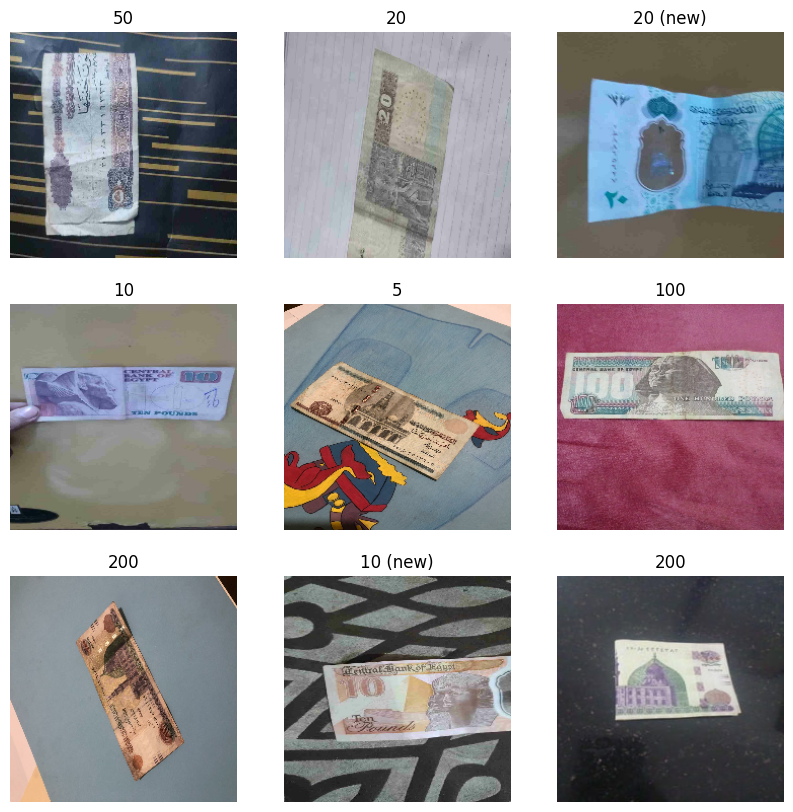

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        # We use the 'class_names' list we saved in the previous cell
        plt.title(class_names[labels[i]])
        plt.axis("off")

##Feature Extraction (HSV Histograms)

In [5]:
def augment_image_logic(img_uint8):
    """
    Exact implementation of the augmentation logic from the previous script.
    Returns a list of augmented images (including the original).
    """
    augmented_images = [img_uint8]
    h, w = img_uint8.shape[:2]

    # 1. Horizontal Flip
    augmented_images.append(cv2.flip(img_uint8, 1))

    # 2. Vertical Flip
    augmented_images.append(cv2.flip(img_uint8, 0))

    # 3. Small Rotation (±10 degrees)
    angle = np.random.uniform(-10, 10)
    rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    augmented_images.append(cv2.warpAffine(img_uint8, rotation_matrix, (w, h)))

    # 4. Brightness Adjustment (±30%)
    brightness_factor = np.random.uniform(0.7, 1.3)
    augmented_images.append(np.clip(img_uint8 * brightness_factor, 0, 255).astype(np.uint8))

    # 5. Contrast Adjustment
    contrast_factor = np.random.uniform(0.7, 1.3)
    mean = np.mean(img_uint8)
    augmented_images.append(np.clip((img_uint8 - mean) * contrast_factor + mean, 0, 255).astype(np.uint8))

    # 6. Gaussian Blur
    kernel_size = np.random.choice([3, 5])
    augmented_images.append(cv2.GaussianBlur(img_uint8, (kernel_size, kernel_size), 0))

    # 7. Salt & Pepper Noise (50% chance)
    if np.random.random() > 0.5:
        noisy = img_uint8.copy()
        amount = np.random.uniform(0.001, 0.005)
        # Salt
        num_salt = np.ceil(amount * img_uint8.size * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_uint8.shape]
        noisy[coords[0], coords[1], :] = 255
        # Pepper
        num_pepper = np.ceil(amount * img_uint8.size * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_uint8.shape]
        noisy[coords[0], coords[1], :] = 0
        augmented_images.append(noisy)

    # 8. Random Cropping (95% of original)
    crop_ratio = np.random.uniform(0.9, 0.95)
    crop_h, crop_w = int(h * crop_ratio), int(w * crop_ratio)
    start_y, start_x = np.random.randint(0, h - crop_h), np.random.randint(0, w - crop_w)
    augmented_images.append(img_uint8[start_y:start_y+crop_h, start_x:start_x+crop_w])

    # 9. Color Jitter (50% chance)
    if np.random.random() > 0.5:
        jittered = img_uint8.copy()
        for channel in range(3):
            shift = np.random.uniform(-20, 20)
            jittered[:, :, channel] = np.clip(jittered[:, :, channel] + shift, 0, 255).astype(np.uint8)
        augmented_images.append(jittered)

    return augmented_images

def extract_combined_features(dataset, is_training=False):
    features = []
    labels = []

    for images, batch_labels in dataset:
        for img, label in zip(images, batch_labels):
            # Convert back to uint8
            img_uint8 = (img.numpy() * 255).astype('uint8')

            # Decide if we apply augmentations
            images_to_process = augment_image_logic(img_uint8) if is_training else [img_uint8]

            for processed_img in images_to_process:
                # Resize for consistency (required if cropped/scaled during augmentation)
                processed_img = cv2.resize(processed_img, (224, 224))

                # --- PART A: HSV FEATURES ---
                img_hsv = cv2.cvtColor(processed_img, cv2.COLOR_RGB2HSV)
                mask = cv2.inRange(img_hsv, (0, 40, 20), (180, 255, 255))
                masked_pixels = img_hsv[mask > 0]

                if len(masked_pixels) > 0:
                    hsv_means = np.mean(masked_pixels, axis=0)
                    hsv_stds = np.std(masked_pixels, axis=0)
                    hsv_skews = skew(masked_pixels, axis=0)
                else:
                    hsv_means = hsv_stds = hsv_skews = np.zeros(3)

                hsv_hist = cv2.calcHist([img_hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
                hsv_hist = cv2.normalize(hsv_hist, hsv_hist).flatten()
                features_hsv = np.hstack([hsv_hist, hsv_means, hsv_stds, hsv_skews])

                # --- PART B: RGB FEATURES ---
                h, w, _ = processed_img.shape
                mh, mw = int(h * 0.1), int(w * 0.1)
                center_crop = processed_img[mh:h-mh, mw:w-mw]
                rgb_hist = cv2.calcHist([center_crop], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
                rgb_hist = cv2.normalize(rgb_hist, rgb_hist).flatten()
                (R, G, B) = cv2.split(center_crop)
                rgb_means = [np.mean(R), np.mean(G), np.mean(B)]
                rgb_stds  = [np.std(R), np.std(G), np.std(B)]
                features_rgb = np.hstack([rgb_hist, rgb_means, rgb_stds])

                # --- PART C: COMBINE ---
                combined_vector = np.hstack([features_hsv, features_rgb])
                features.append(combined_vector)
                labels.append(label.numpy())

    return np.array(features), np.array(labels)


print("Extracting Train (with Augmentation)...")
X_train, y_train = extract_combined_features(train_ds, is_training=True)

print("Extracting Validation (No Augmentation)...")
X_val, y_val = extract_combined_features(val_ds, is_training=False)

print("Extracting Test (No Augmentation)...")
X_test, y_test = extract_combined_features(test_ds, is_training=False)

Extracting Train (with Augmentation)...


/tmp/ipython-input-2176940047.py:87: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  hsv_skews = skew(masked_pixels, axis=0)


Extracting Validation (No Augmentation)...
Extracting Test (No Augmentation)...


## Model Training

In [12]:
model = XGBClassifier(
    n_estimators=3000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    random_state=42,
    reg_alpha=0.5,             # L1 regularization to fight noise
    reg_lambda=5,              # L2 regularization to fight noise
    early_stopping_rounds=20   # STOP if validation score doesn't improve for 20 rounds
)

print("Training with Early Stopping...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50  # Prints progress every 50 epochs/rounds
)

print(f"Stopped at epoch: {model.best_iteration}")

print("Model training finished!")

Training with Early Stopping...
[0]	validation_0-mlogloss:2.10825	validation_1-mlogloss:2.11944
[50]	validation_0-mlogloss:0.74074	validation_1-mlogloss:0.95674
[100]	validation_0-mlogloss:0.41600	validation_1-mlogloss:0.66808
[150]	validation_0-mlogloss:0.27270	validation_1-mlogloss:0.53510
[200]	validation_0-mlogloss:0.19206	validation_1-mlogloss:0.45804
[250]	validation_0-mlogloss:0.13990	validation_1-mlogloss:0.40246
[300]	validation_0-mlogloss:0.10325	validation_1-mlogloss:0.36531
[350]	validation_0-mlogloss:0.07789	validation_1-mlogloss:0.33606
[400]	validation_0-mlogloss:0.05934	validation_1-mlogloss:0.31406
[450]	validation_0-mlogloss:0.04635	validation_1-mlogloss:0.29612
[500]	validation_0-mlogloss:0.03675	validation_1-mlogloss:0.28242
[550]	validation_0-mlogloss:0.02972	validation_1-mlogloss:0.27095
[600]	validation_0-mlogloss:0.02449	validation_1-mlogloss:0.26200
[650]	validation_0-mlogloss:0.02051	validation_1-mlogloss:0.25473
[700]	validation_0-mlogloss:0.01751	validation_

Top 10 Most Important Features:
RGB_98     0.022247
RGB_171    0.019380
RGB_405    0.016311
RGB_89     0.013595
HSV_319    0.009521
HSV_405    0.008575
RGB_46     0.008507
RGB_496    0.007754
RGB_162    0.007569
RGB_395    0.007508
dtype: float32


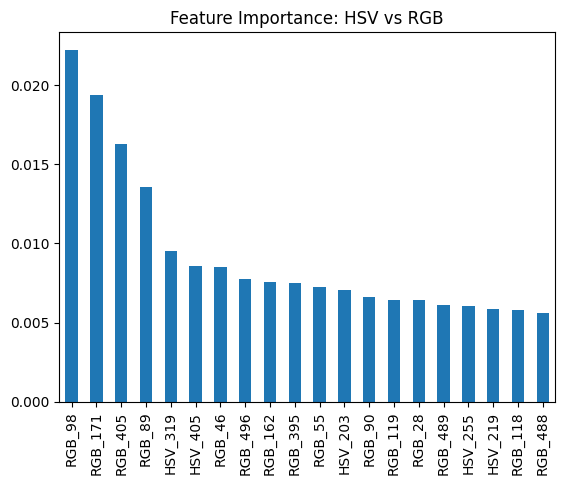

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get feature importance
importances = model.feature_importances_

# 2. Create a naming convention to track which feature came from where
# HSV has 521 features, RGB has 518. Total = 1039
hsv_labels = [f"HSV_{i}" for i in range(521)]
rgb_labels = [f"RGB_{i}" for i in range(518)]
all_labels = hsv_labels + rgb_labels

# 3. Plot top 20 features
feature_imp = pd.Series(importances, index=all_labels).sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(feature_imp.head(10))

# Visual check: Are both HSV and RGB in the top 20?
feature_imp.head(20).plot(kind='bar')
plt.title("Feature Importance: HSV vs RGB")
plt.show()

# Evaluation
Testing the model on images it has never seen before to calculate the final accuracy.

Overall Accuracy: 92.18%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           1       0.94      1.00      0.97        16
          10       0.85      0.95      0.90        64
    10 (new)       0.94      0.96      0.95        48
         100       0.92      0.92      0.92        63
          20       0.88      0.92      0.90        66
    20 (new)       1.00      0.93      0.96        58
         200       0.90      0.88      0.89        64
           5       0.96      0.86      0.91        56
          50       0.95      0.94      0.94        64

    accuracy                           0.92       499
   macro avg       0.93      0.93      0.93       499
weighted avg       0.92      0.92      0.92       499



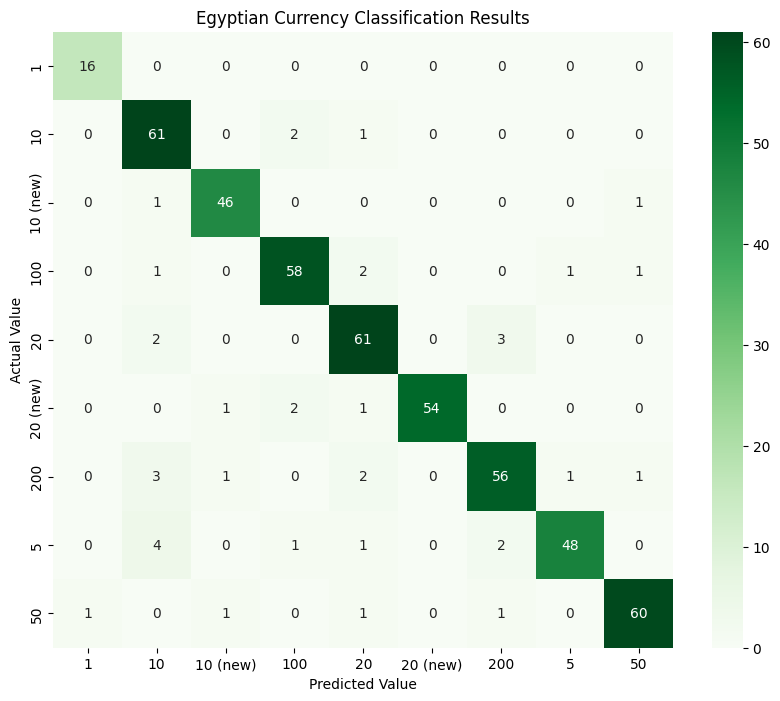

In [14]:
# Make predictions
y_pred = model.predict(X_val)

# Print Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# Detailed Report
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=class_names))

# Visualize with a Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Egyptian Currency Classification Results')
plt.show()

Training Accuracy: 99.98%
------------------------------
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       579
          10       1.00      1.00      1.00      2303
    10 (new)       1.00      1.00      1.00      1649
         100       1.00      1.00      1.00      2281
          20       1.00      1.00      1.00      2341
    20 (new)       1.00      1.00      1.00      2089
         200       1.00      1.00      1.00      2260
           5       1.00      1.00      1.00      1980
          50       1.00      1.00      1.00      2209

    accuracy                           1.00     17691
   macro avg       1.00      1.00      1.00     17691
weighted avg       1.00      1.00      1.00     17691



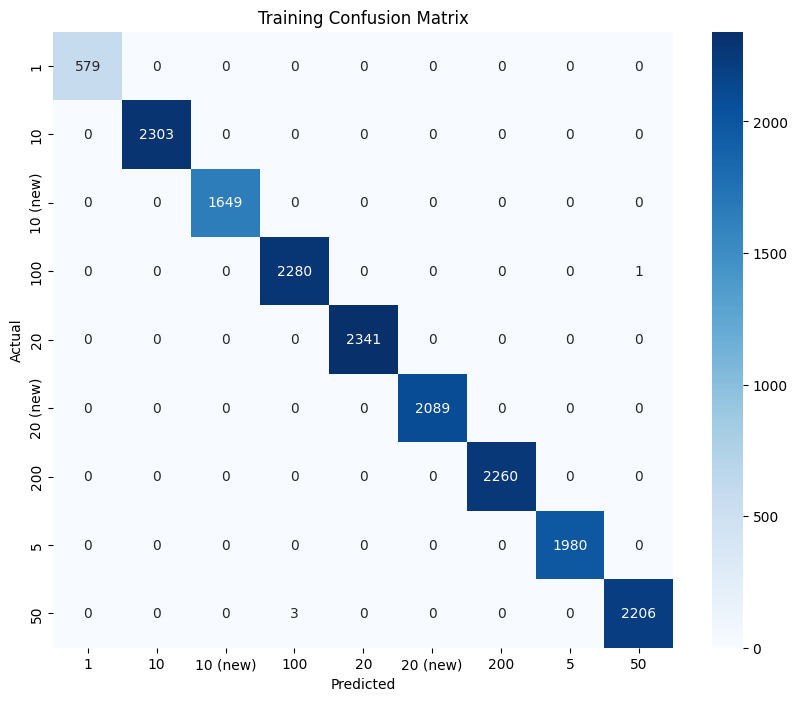

In [10]:
# ===== Evaluate on Training Data =====
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print("-" * 30)

print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=class_names))

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Confusion Matrix')
plt.show()


Test Accuracy: 93.09%
------------------------------
Test Classification Report:
              precision    recall  f1-score   support

           1       0.91      1.00      0.95        20
          10       0.90      0.93      0.91        80
    10 (new)       0.97      0.97      0.97        60
         100       0.93      0.96      0.94        80
          20       0.91      0.89      0.90        82
    20 (new)       0.99      1.00      0.99        72
         200       0.92      0.90      0.91        80
           5       0.91      0.87      0.89        70
          50       0.94      0.92      0.93        78

    accuracy                           0.93       622
   macro avg       0.93      0.94      0.93       622
weighted avg       0.93      0.93      0.93       622



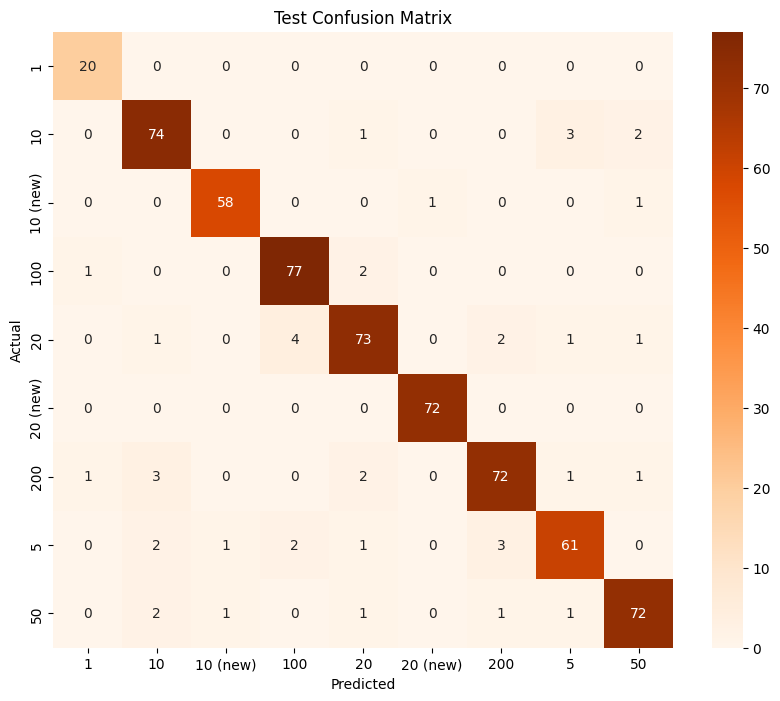

In [15]:
# ===== Evaluate on Test Data =====
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("-" * 30)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Oranges'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()
